# Benchmark Analysis

Loads benchmark results and produces thesis-quality figures and tables.

**Expected outputs:**
1. Summary heatmap (Gamma by scenario x method)
2. Per-parameter recovery bar charts (membrane vs adaptation)
3. Loss convergence comparison
4. Multi-start distribution (box plots of Gamma)
5. Wall time comparison
6. Firing pattern difficulty ranking
7. LaTeX tables for thesis

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path(".").resolve().parent))

from ADoptEX.benchmark import (
    load_all_results,
    summary_table,
    recovery_table,
    print_table,
    format_latex_table,
)
from ADoptEX.benchmark.scenarios import FULL_PARAMS, MEMBRANE_PARAMS

## Load Results

In [11]:
RESULTS_DIR = Path("results/tonic")
results = load_all_results(RESULTS_DIR)
print(f"Loaded {len(results)} result files")

# Summary table
df = pd.DataFrame(summary_table(results))
df

Loaded 46 result files


,scenario,method,n_runs,mean_gamma,best_gamma,std_gamma,mean_loss,best_loss,mean_wall_time_s,total_wall_time_s
0,tonic_gt00_15pct_membrane,nelder_mead,10,0.932796,1.000000,0.106591,1.928408,0.310411,1.152221,11.522213
1,tonic_gt00_1pct_membrane,grad_guarino,10,0.413445,1.000000,0.456794,NaN,NaN,0.699798,6.997981
2,tonic_gt00_1pct_membrane,grad_vanrossum,3,0.006993,0.006993,0.000000,7.014368,7.009125,22.520712,67.562135
3,tonic_gt00_5pct_membrane,grad_guarino,10,0.286688,1.000000,0.349990,0.489858,0.156383,8.323332,83.233322
4,tonic_gt00_5pct_membrane,grad_vanrossum,10,0.349020,1.000000,0.309131,7.148943,6.585699,4.593360,45.933602
5,tonic_gt01_15pct_membrane,nelder_mead,10,0.680541,1.000000,0.324892,2.061963,0.107904,1.183133,11.831331
6,tonic_gt01_5pct_membrane,grad_guarino,10,0.033789,0.130275,0.055773,1.516030,0.428620,6.337398,63.373978
7,tonic_gt01_5pct_membrane,grad_vanrossum,10,0.077932,0.273478,0.101498,7.175477,5.972243,5.618001,56.180012
8,tonic_gt02_15pct_membrane,nelder_mead,10,0.828913,1.000000,0.276040,1.773906,0.010050,1.125711,11.257112
9,tonic_gt02_5pct_membrane,grad_guarino,10,-0.004672,0.150000,0.107778,NaN,NaN,0.614642,6.146420


## 1. Summary Heatmap: Gamma by Scenario x Method

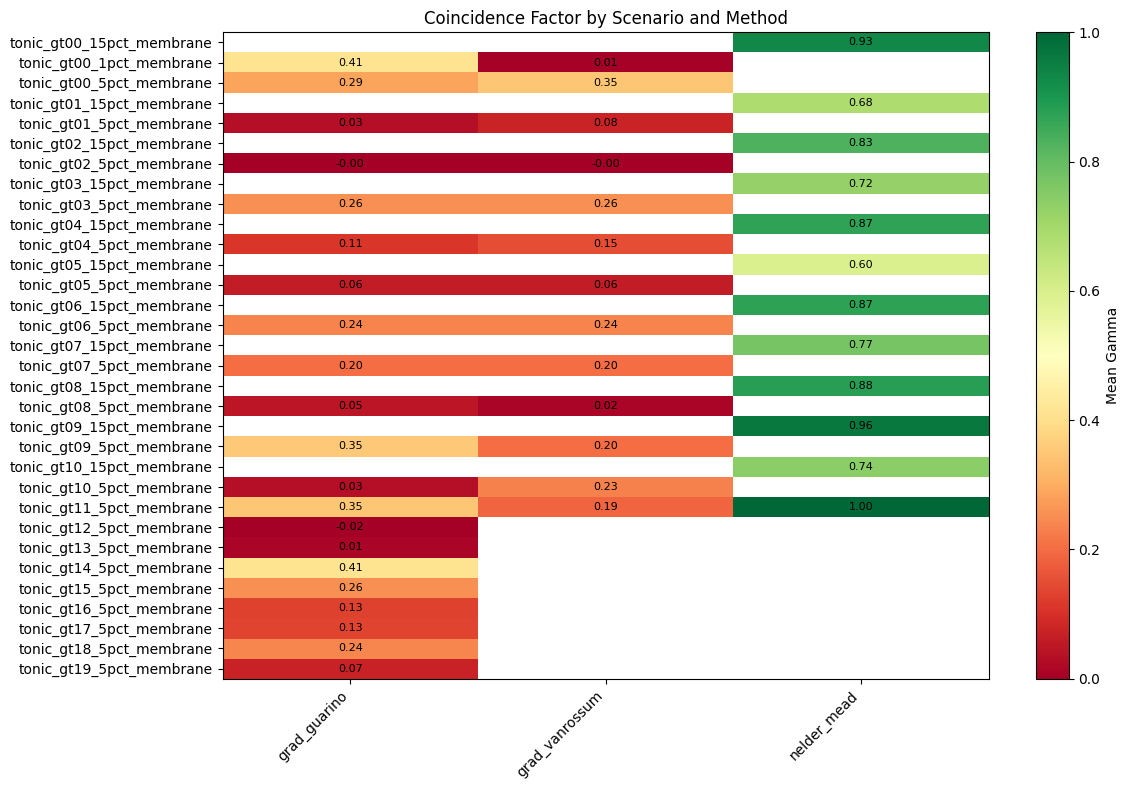

In [12]:
if not df.empty:
    pivot = df.pivot_table(index="scenario", columns="method", values="mean_gamma")
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    # Annotate cells
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, label="Mean Gamma")
    ax.set_title("Coincidence Factor by Scenario and Method")
    plt.tight_layout()
    plt.savefig("gamma_heatmap.pdf", bbox_inches="tight")
    plt.show()

## 2. Per-Parameter Recovery

In [13]:
if not df.empty:
    rec_rows = recovery_table(results, FULL_PARAMS)
    if rec_rows:
        rec_df = pd.DataFrame(rec_rows)
        print_table(rec_rows)
    else:
        print("No recovery data (experimental scenarios only?)")

scenario                  | method         | parameter | n_runs | mean_error_pct | best_error_pct | std_error_pct | mean
------------------------------------------------------------------------------------------------------------------------
tonic_gt00_15pct_membrane | nelder_mead    | C_m       | 10     | 4.6887         | 0.4630         | 4.0014        | 9.37
tonic_gt00_15pct_membrane | nelder_mead    | g_L       | 10     | 8.1130         | 1.0818         | 3.4396        | 0.81
tonic_gt00_15pct_membrane | nelder_mead    | E_L       | 10     | 4.9324         | 0.8480         | 3.1689        | 4.43
tonic_gt00_15pct_membrane | nelder_mead    | v_T       | 10     | 5.4993         | 0.4028         | 3.9358        | 3.05
tonic_gt00_15pct_membrane | nelder_mead    | delta_T   | 10     | 7.0618         | 0.6865         | 4.5784        | 0.28
tonic_gt00_15pct_membrane | nelder_mead    | v_reset   | 10     | 6.7611         | 1.6691         | 3.7799        | 4.73
tonic_gt00_1pct_membrane  | grad

## 3. Loss Convergence Comparison

In [14]:
# Plot loss curves for best run of each method on a representative scenario
if results:
    target_scenario = "tonic_15pct_full"
    scenario_results = [r for r in results if r.scenario_name == target_scenario]
    if scenario_results:
        fig, ax = plt.subplots(figsize=(10, 6))
        for sr in scenario_results:
            if sr.best_run and sr.best_run.loss_history:
                ax.semilogy(sr.best_run.loss_history, label=sr.method_name)
        ax.set_xlabel("Epoch / Function Evaluation")
        ax.set_ylabel("Loss")
        ax.set_title(f"Loss Convergence: {target_scenario}")
        ax.legend()
        plt.tight_layout()
        plt.savefig("figures/loss_convergence.pdf", bbox_inches="tight")
        plt.show()

## 4. Multi-Start Distribution (Box Plots)

/var/folders/lr/n5b_gtwn3fn_tq12xz4vwplc0000gn/T/ipykernel_9482/3676721812.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(method_gammas.values(), labels=method_gammas.keys())


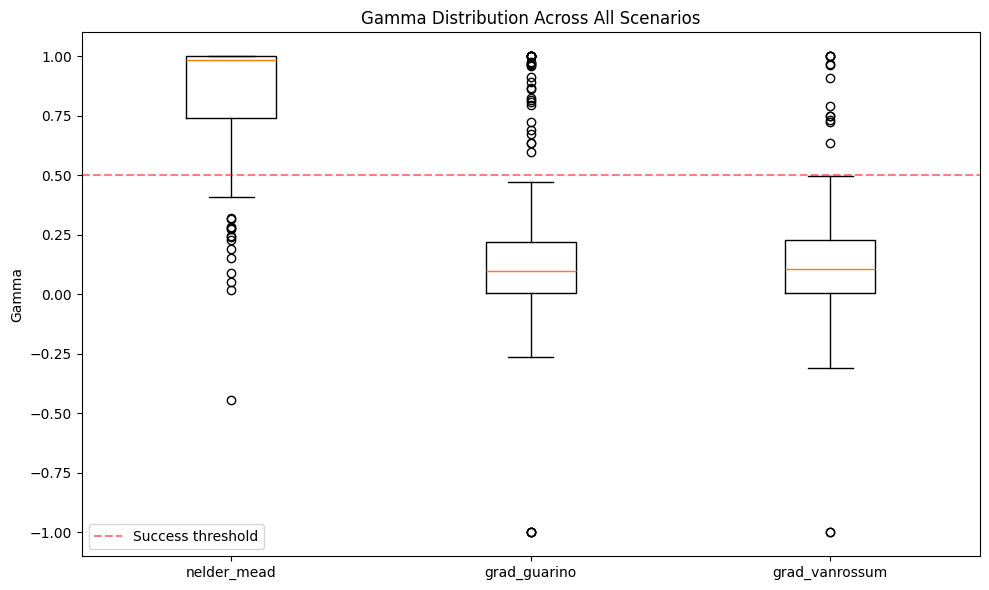

In [15]:
if results:
    # Collect gamma distributions per method
    method_gammas = {}
    for sr in results:
        gammas = [r.gamma for r in sr.runs if r.gamma is not None and not np.isnan(r.gamma)]
        if gammas:
            method_gammas.setdefault(sr.method_name, []).extend(gammas)
    
    if method_gammas:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(method_gammas.values(), labels=method_gammas.keys())
        ax.set_ylabel("Gamma")
        ax.set_title("Gamma Distribution Across All Scenarios")
        ax.axhline(y=0.5, color="r", linestyle="--", alpha=0.5, label="Success threshold")
        ax.legend()
        plt.tight_layout()
        plt.savefig("gamma_boxplot.pdf", bbox_inches="tight")
        plt.show()

## 5. Wall Time Comparison

FileNotFoundError: [Errno 2] No such file or directory: 'figures/wall_time.pdf'

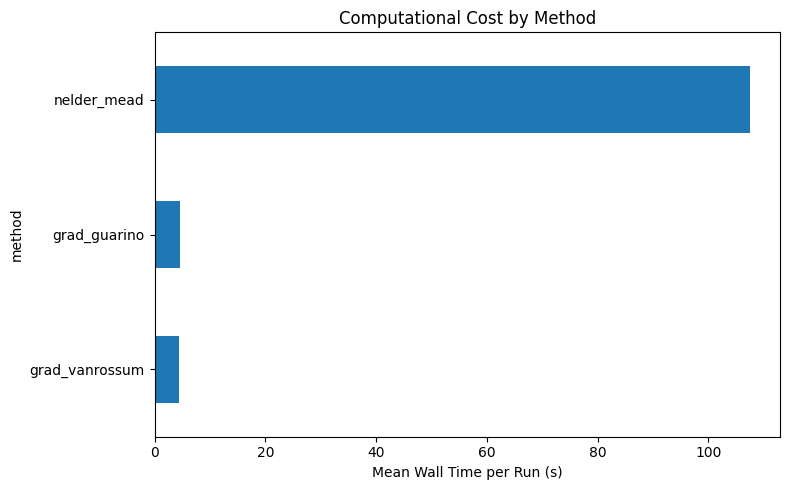

In [16]:
if not df.empty:
    time_df = df.groupby("method")["mean_wall_time_s"].mean().sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    time_df.plot(kind="barh", ax=ax)
    ax.set_xlabel("Mean Wall Time per Run (s)")
    ax.set_title("Computational Cost by Method")
    plt.tight_layout()
    plt.savefig("wall_time.pdf", bbox_inches="tight")
    plt.show()

## 6. LaTeX Tables

In [16]:
if not df.empty:
    # Main results table
    table_rows = summary_table(results)
    latex = format_latex_table(
        [{k: v for k, v in r.items() if k in ("scenario", "method", "mean_gamma", "best_gamma", "mean_loss", "mean_wall_time_s")}
         for r in table_rows],
        caption="Benchmark results: coincidence factor and loss across scenarios and methods"
    )
    print(latex)